In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!cp -r /content/drive/MyDrive/train /content/
!cp -r /content/drive/MyDrive/eval /content/

In [3]:
from pathlib import Path
from PIL import Image

import random
import matplotlib.pylab as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader,Dataset
import torchvision.models as models
from torchvision import transforms

In [4]:
DATA_ROOT=Path("/content")
TRAIN_PATH=DATA_ROOT/"train"
EVAL_PATH=DATA_ROOT/"eval"
TEST_PATH=DATA_ROOT/"test"

In [5]:
# Print the folders in train folder:
for i in TRAIN_PATH.iterdir():
  print(i.name)

street
sea
forest
buildings
mountain
glacier


In [6]:
train_image=list(TRAIN_PATH.rglob("*.jpg"))
print(f"The total number of images in train dataset is:{len(train_image)}")

The total number of images in train dataset is:14034


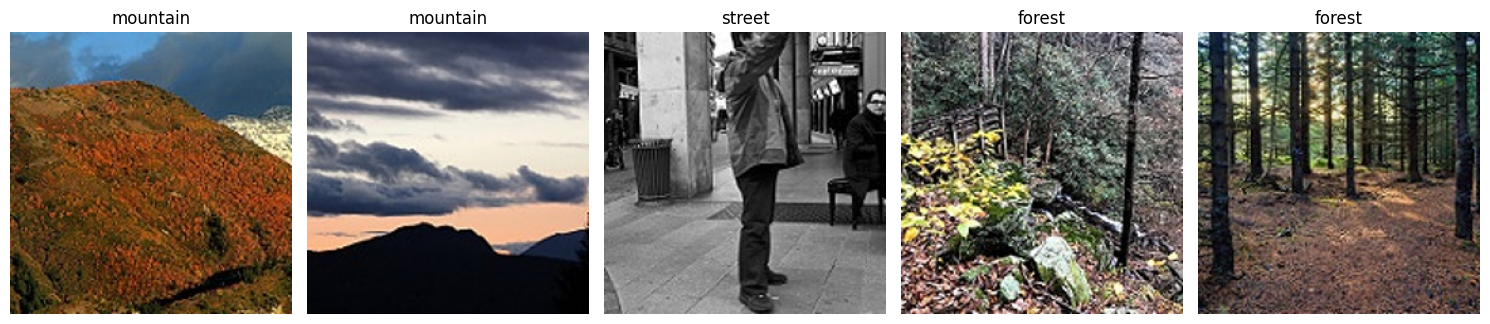

In [7]:
fig,axes=plt.subplots(1,5,figsize=(15,6))
for img in range(5):
  image=random.choice(train_image)
  image_name=image.parent.name
  image=Image.open(image).convert("RGB").resize((224,224))

  axes[img].imshow(image)
  axes[img].set_title(image_name)
  axes[img].axis("off")

plt.tight_layout()
plt.show()


In [8]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [9]:
class CustomDataset(Dataset):

  def __init__(self,root_path,transformation=None):
    super().__init__()
    self.root=Path(root_path)
    self.transformation=transformation
    self.labels=[]
    self.images=[]

    classes=["street","sea","forest","buildings","mountain","glacier"]

    for idx,class_name in enumerate(classes):
      folder_name=self.root/class_name

      for img in folder_name.iterdir():
        if img.suffix.lower() in ['.jpg','.jpeg','.png']:
          self.images.append(img)
          self.labels.append(idx)
  def __len__(self):
    return len(self.images)

  def __getitem__(self, index):
    image=self.images[index]
    image=Image.open(image).convert("RGB")
    label=torch.tensor(self.labels[index],dtype=torch.long)

    if self.transformation:
      image=self.transformation(image)

    return image,label


In [10]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [11]:
train_data=CustomDataset(TRAIN_PATH,transformation=transform)
eval_data=CustomDataset(EVAL_PATH,transformation=transform)

In [12]:
train_dataloader=DataLoader(train_data,shuffle=True,batch_size=32)
eval_dataloader=DataLoader(eval_data,shuffle=False,batch_size=32)

In [13]:
model = models.resnet50(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [14]:
for param in model.parameters():
  param.requires_grad=False

In [15]:
model.fc=nn.Linear(model.fc.in_features,6)
model=model.to(device)

In [16]:
loss=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=1e-4)
epochs=10

In [20]:
history={'train_loss':[],'eval_loss':[],'train_accuracy':[],'eval_accuracy':[]}
for epoch in range(epochs):
  t_loss,t_count,t_correct=0,0,0
  model.train()
  for batch_feature,batch_label in train_dataloader:
    batch_feature,batch_label=batch_feature.to(device),batch_label.to(device)

    optimizer.zero_grad()
    output=model(batch_feature)
    model_loss=loss(output,batch_label)
    model_loss.backward()
    optimizer.step()

    _,predicted=torch.max(output,1)
    t_count+=batch_feature.size(0)
    t_correct+=(predicted==batch_label).sum().item()

    t_loss+=model_loss.item()

  model.eval()
  v_loss,v_count,v_correct=0,0,0
  with torch.no_grad():
    for batch_feature,batch_label in eval_dataloader:
      batch_feature,batch_label=batch_feature.to(device),batch_label.to(device)
      output=model(batch_feature)
      model_loss=loss(output,batch_label)

      _,predicted=torch.max(output,1)
      v_count+=batch_feature.size(0)
      v_correct+=(predicted==batch_label).sum().item()
      v_loss+=model_loss.item()

    history['train_loss'].append(t_loss/len(train_dataloader))
    history['eval_loss'].append(v_loss/len(eval_dataloader))
    history['train_accuracy'].append(t_correct/t_count)
    history['eval_accuracy'].append(v_correct/v_count)

    print(f"Epoch {epoch+1}; Train Loss: {history['train_loss'][-1]:.4f}; Eval Loss: {history['eval_loss'][-1]:.4f}; Train Accuracy: {history['train_accuracy'][-1]:.4f}; Eval Accuracy: {history['eval_accuracy'][-1]:.4f}")


Epoch 1; Train Loss: 0.2673; Eval Loss: 0.2502; Train Accuracy: 0.9044; Eval Accuracy: 0.9090
Epoch 2; Train Loss: 0.2588; Eval Loss: 0.2533; Train Accuracy: 0.9068; Eval Accuracy: 0.9033
Epoch 3; Train Loss: 0.2567; Eval Loss: 0.2412; Train Accuracy: 0.9082; Eval Accuracy: 0.9140
Epoch 4; Train Loss: 0.2534; Eval Loss: 0.2369; Train Accuracy: 0.9094; Eval Accuracy: 0.9153
Epoch 5; Train Loss: 0.2522; Eval Loss: 0.2430; Train Accuracy: 0.9091; Eval Accuracy: 0.9113
Epoch 6; Train Loss: 0.2454; Eval Loss: 0.2374; Train Accuracy: 0.9121; Eval Accuracy: 0.9087
Epoch 7; Train Loss: 0.2451; Eval Loss: 0.2396; Train Accuracy: 0.9122; Eval Accuracy: 0.9110
Epoch 8; Train Loss: 0.2437; Eval Loss: 0.2386; Train Accuracy: 0.9131; Eval Accuracy: 0.9110
Epoch 9; Train Loss: 0.2405; Eval Loss: 0.2378; Train Accuracy: 0.9139; Eval Accuracy: 0.9140
Epoch 10; Train Loss: 0.2400; Eval Loss: 0.2350; Train Accuracy: 0.9158; Eval Accuracy: 0.9083


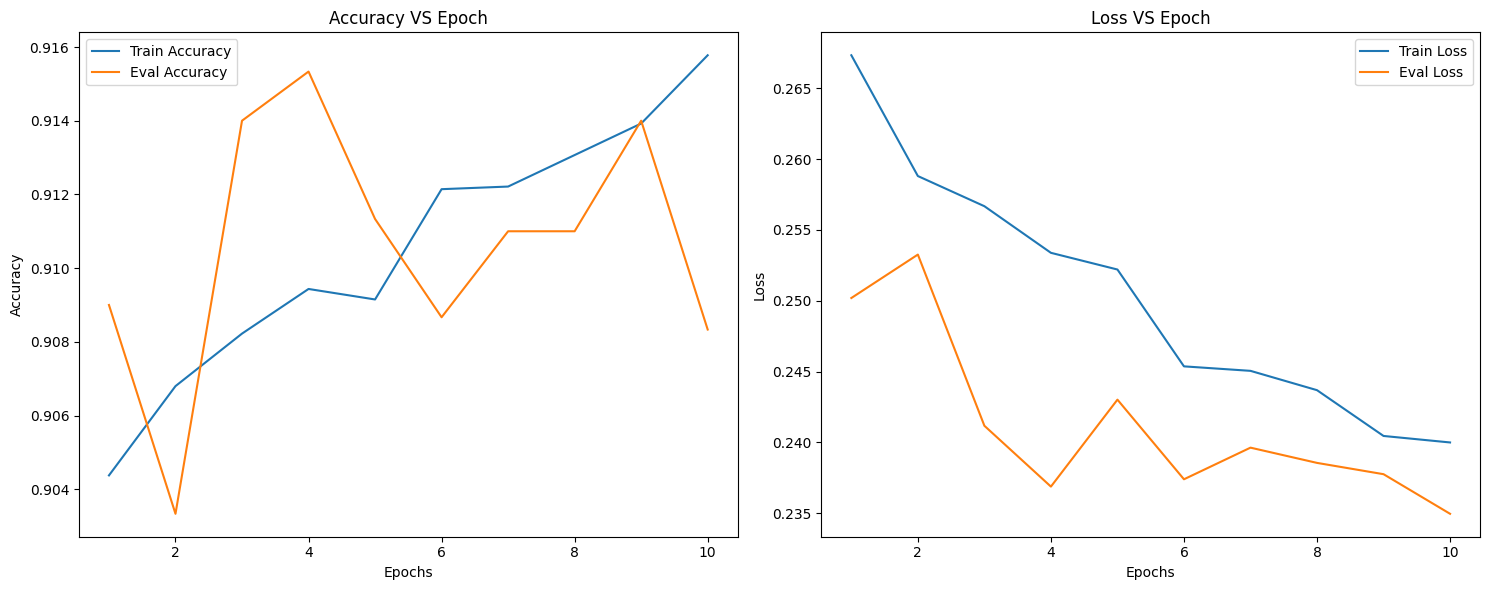

In [23]:
fig,axes=plt.subplots(1,2,figsize=(15,6))

axes[0].plot(range(1,epochs+1),history['train_accuracy'],label='Train Accuracy')
axes[0].plot(range(1,epochs+1),history['eval_accuracy'],label='Eval Accuracy')
axes[0].set_title('Accuracy VS Epoch')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(range(1,epochs+1),history['train_loss'],label='Train Loss')
axes[1].plot(range(1,epochs+1),history['eval_loss'],label='Eval Loss')
axes[1].set_title('Loss VS Epoch')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()